In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import ast # For converting string representations of lists back to lists
from collections import Counter
from pathlib import Path
from wordcloud import WordCloud

# Set plotting style and parameters for better aesthetics
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

print("─" * 80)
print("▶ [STEP 1] Loading the final, clean dataset...")
print("─" * 80)

# Define the path to your final dataset
DATA_PATH = Path("D:/preprocessed_data/preprocessed_data/MM-Food-Cleaned-Final.csv")

if not DATA_PATH.exists():
    print(f"ERROR: Dataset file not found at '{DATA_PATH}'. Please ensure the path is correct.")
else:
    df = pd.read_csv(DATA_PATH)
    print(f"Successfully loaded the clean dataset with {len(df)} rows and {df.shape[1]} columns.")
    
    # Convert string representation of list back to actual list for analysis
    df['ingredients'] = df['ingredients'].apply(ast.literal_eval)
    # Convert date column to datetime objects for time-series analysis
    df['submission_date'] = pd.to_datetime(df['submission_date'])

    print("\nDataset Information:")
    df.info()
    
    print("\nFirst 5 rows of the clean dataset:")
    from IPython.display import display
    display(df.head())

────────────────────────────────────────────────────────────────────────────────
▶ [STEP 1] Loading the final, clean dataset...
────────────────────────────────────────────────────────────────────────────────
Successfully loaded the clean dataset with 10996 rows and 17 columns.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10996 entries, 0 to 10995
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dish_name                10996 non-null  object        
 1   image_filepath           10996 non-null  object        
 2   submission_date          10996 non-null  datetime64[ns]
 3   food_type                10996 non-null  object        
 4   food_type.1              10996 non-null  object        
 5   cooking_method           10888 non-null  object        
 6   ingredients              10996 non-null  object        
 7   total_grams              10996 non-n

,dish_name,image_filepath,submission_date,food_type,food_type.1,cooking_method,ingredients,total_grams,is_duplicate_image,calories_kcal,fat_g,protein_g,carbohydrate_g,calories_kcal_per_100g,fat_g_per_100g,protein_g_per_100g,carbohydrate_g_per_100g
0,spicy crab,preprocessed_data\images_processed\0a0c19eb67a...,2025-07-05,Restaurant food,restaurant food,stir-fried,"[crab, sauce, spices, vegetables]",450.0,False,500,20.0,40.0,10.0,111.111111,4.444444,8.888889,2.222222
1,steamed snails,preprocessed_data\images_processed\066b7ba6197...,2025-07-01,Homemade food,homemade food,steamed,"[dipping sauce, garlic, herbs, snails]",350.0,False,200,5.0,30.0,10.0,57.142857,1.428571,8.571429,2.857143
2,chicken stirfry,preprocessed_data\images_processed\fecd381a783...,2025-07-18,Homemade food,homemade food,stir-frying,"[bell peppers, chicken, onions, soy sauce]",450.0,False,450,20.0,30.0,25.0,100.000000,4.444444,6.666667,5.555556
3,grilled salmon,preprocessed_data\images_processed\01e3ca00199...,2025-07-19,Restaurant food,restaurant food,Grilling,"[butter sauce, herbs, salmon]",250.0,False,350,20.0,30.0,5.0,140.000000,8.000000,12.000000,2.000000
4,braised pork belly,preprocessed_data\images_processed\34256ac8f85...,2025-07-04,Restaurant food,restaurant food,Braised,"[Green Onion, Pork Belly, Rice, Soy Sauce]",350.0,False,600,30.0,25.0,50.0,171.428571,8.571429,7.142857,14.285714


────────────────────────────────────────────────────────────────────────────────
▶ [STEP 2] Generating High-Level Statistical Overview...
────────────────────────────────────────────────────────────────────────────────

Summary statistics for key numerical columns:


,total_grams,calories_kcal,fat_g,protein_g,carbohydrate_g
count,10996.00,10996.00,10996.00,10996.00,10996.00
mean,363.93,416.26,17.79,21.58,41.13
std,179.83,256.20,15.00,18.07,29.39
min,0.00,0.00,0.00,0.00,0.00
25%,250.00,250.00,10.00,6.00,20.00
50%,350.00,350.00,15.00,20.00,36.00
75%,450.00,600.00,22.00,30.00,60.00
max,5000.00,3500.00,250.00,250.00,400.00



Analysis of Categorical Features:


C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\3885089582.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['food_type'], order=df['food_type'].value_counts().index, palette='viridis')


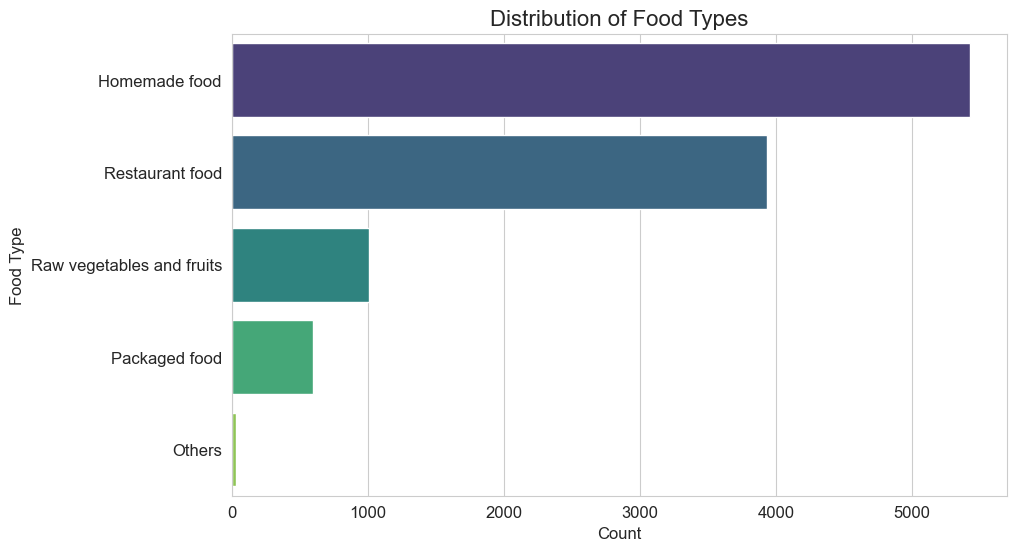

C:\Users\Neelanjan Dutta\AppData\Local\Temp\ipykernel_24740\3885089582.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['cooking_method'], order=top_10_cooking.index, palette='plasma')


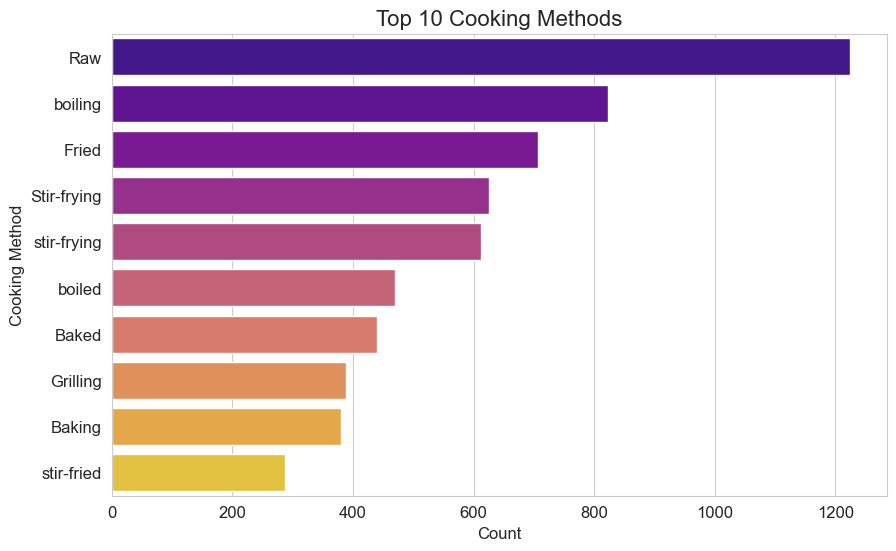

In [2]:
print("─" * 80)
print("▶ [STEP 2] Generating High-Level Statistical Overview...")
print("─" * 80)

# --- Numerical Summary ---
print("\nSummary statistics for key numerical columns:")
numerical_cols = ['total_grams', 'calories_kcal', 'fat_g', 'protein_g', 'carbohydrate_g']
from IPython.display import display
display(df[numerical_cols].describe().round(2))

# --- Categorical Analysis ---
print("\nAnalysis of Categorical Features:")

# Plot for 'food_type'
plt.figure(figsize=(10, 6))
sns.countplot(y=df['food_type'], order=df['food_type'].value_counts().index, palette='viridis')
plt.title('Distribution of Food Types', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Food Type')
plt.show()

# Plot for 'cooking_method'
plt.figure(figsize=(10, 6))
top_10_cooking = df['cooking_method'].value_counts().nlargest(10)
sns.countplot(y=df['cooking_method'], order=top_10_cooking.index, palette='plasma')
plt.title('Top 10 Cooking Methods', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Cooking Method')
plt.show()

────────────────────────────────────────────────────────────────────────────────
▶ [STEP 3] Analyzing Data Submissions Over Time...
────────────────────────────────────────────────────────────────────────────────


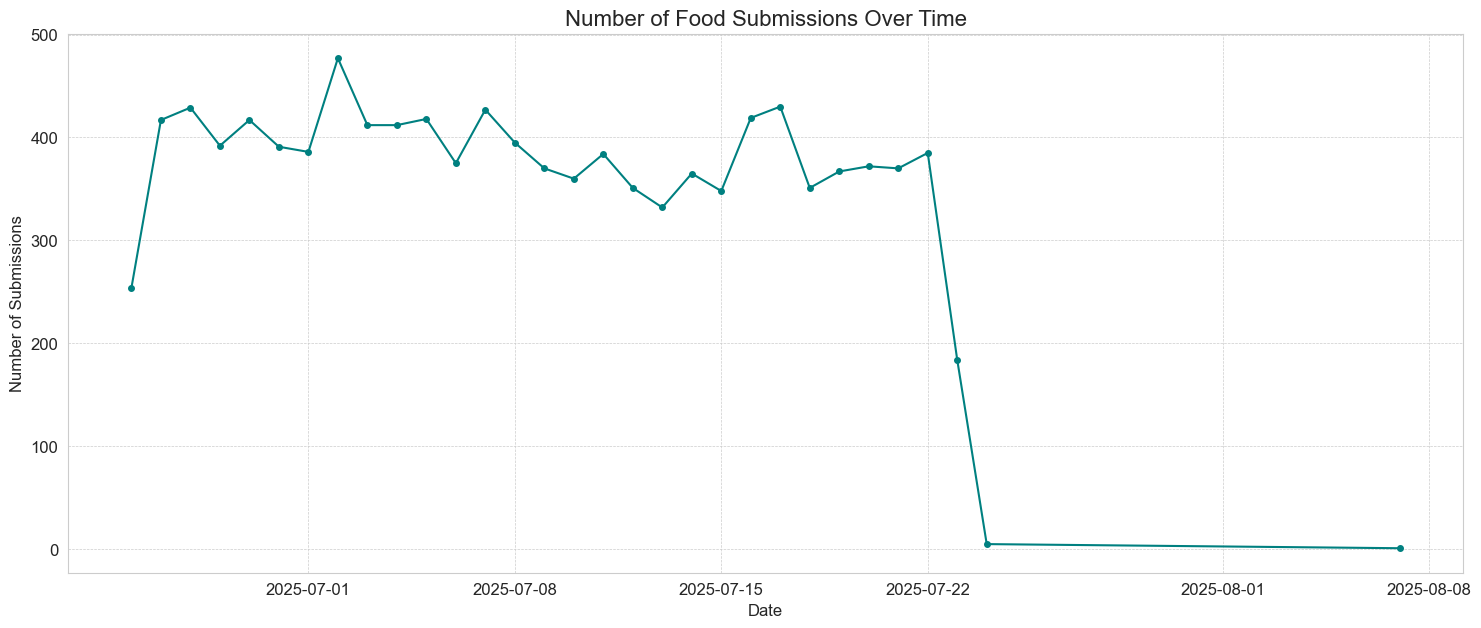

In [3]:
print("─" * 80)
print("▶ [STEP 3] Analyzing Data Submissions Over Time...")
print("─" * 80)

# Group data by date and count the number of submissions
submissions_by_day = df.groupby(df['submission_date'].dt.date).size()

plt.figure(figsize=(18, 7))
submissions_by_day.plot(kind='line', marker='o', linestyle='-', markersize=4, color='teal')
plt.title('Number of Food Submissions Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Submissions', fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()